# Crop Fields

Crop từng field (id, name, birth, origin, address, title) ra thành ảnh nhỏ từ bbox annotation.

**Đầu vào:**
- `data/processed/splits/train.json` + `val.json` (COCO JSON)
- Ảnh gốc từ `data/cccd.v1i.coco/`

**Đầu ra:**
- `data/interim/cropped_fields/{class}/{image_stem}_{ann_id}.jpg`
- `data/interim/cropped_fields/manifest.jsonl` — index toàn bộ crop

## 1. Setup

In [2]:
pip install opencv-python matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import json
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

PROJECT_DIR  = Path("d:/TaiLieuHocTap/Extraction ID Card")  
os.chdir(PROJECT_DIR)

RAW_DIR     = PROJECT_DIR / "data/cccd.v1i.coco"
SPLITS_DIR  = PROJECT_DIR / "data/processed/splits"
OUT_DIR     = PROJECT_DIR / "data/interim/cropped_fields"

FIELD_CLASSES = ["id", "name", "birth", "origin", "address", "title"]
PADDING       = 4    # px padding quanh bbox
MIN_SIZE      = 10   # bỏ qua crop quá nhỏ (px)

# Tạo thư mục output
for cls in FIELD_CLASSES:
    (OUT_DIR / cls).mkdir(parents=True, exist_ok=True)

# Build bảng tra cứu ảnh: filename → path
fname_to_path = {}
for split in ["train", "valid", "test"]:
    for p in (RAW_DIR / split).glob("*.jpg"):
        fname_to_path[p.name] = p

print(f"{len(fname_to_path)} anh goc")

4399 anh goc


## 2. Crop fields

In [4]:
def crop_split(json_path: Path, split_name: str, cat_id_to_name: dict) -> list:
    with open(json_path, encoding="utf-8") as f:
        coco = json.load(f)

    cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    img_id_to_info = {img["id"]: img for img in coco["images"]}

    records = []
    skipped = 0

    for ann in tqdm(coco["annotations"], desc=f"  {split_name}", leave=False):
        cls = cat_id_to_name.get(ann["category_id"])
        if cls not in FIELD_CLASSES:
            continue

        img_info = img_id_to_info[ann["image_id"]]
        src = fname_to_path.get(img_info["file_name"])
        if src is None:
            skipped += 1
            continue

        image = cv2.imread(str(src))
        if image is None:
            skipped += 1
            continue

        h, w = image.shape[:2]
        x, y, bw, bh = ann["bbox"]
        x1 = max(0, int(x) - PADDING)
        y1 = max(0, int(y) - PADDING)
        x2 = min(w, int(x + bw) + PADDING)
        y2 = min(h, int(y + bh) + PADDING)

        if (x2 - x1) < MIN_SIZE or (y2 - y1) < MIN_SIZE:
            skipped += 1
            continue

        crop = image[y1:y2, x1:x2]
        stem = Path(img_info["file_name"]).stem
        out_name = f"{stem}_{ann['id']}.jpg"
        out_path = OUT_DIR / cls / out_name
        cv2.imwrite(str(out_path), crop)

        records.append({
            "path": str(out_path.relative_to(PROJECT_DIR)),
            "class": cls,
            "split": split_name,
            "source_image": img_info["file_name"],
            "ann_id": ann["id"],
            "bbox": [x1, y1, x2, y2],
            "width": x2 - x1,
            "height": y2 - y1,
        })

    print(f"  {split_name}: {len(records)} crops, bo qua {skipped}")
    return records


all_records = []
for split_name, fname in [("train", "train.json"), ("val", "val.json")]:
    records = crop_split(SPLITS_DIR / fname, split_name, {})
    all_records.extend(records)

print(f"\nTong: {len(all_records)} crops")

  train:   0%|          | 0/21535 [00:00<?, ?it/s]

  train: 18476 crops, bo qua 0


  val:   0%|          | 0/4905 [00:00<?, ?it/s]

  val: 4206 crops, bo qua 0

Tong: 22682 crops


## 3. Lưu manifest

In [5]:
manifest_path = OUT_DIR / "manifest.jsonl"
with open(manifest_path, "w", encoding="utf-8") as f:
    for rec in all_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

## 4. Thống kê

Số lượng crop theo class:
  id        :  3769
  name      :  3795
  birth     :  3773
  origin    :  3816
  address   :  3756
  title     :  3773
Số lượng crop theo split:
  train : 18476
  val   : 4206


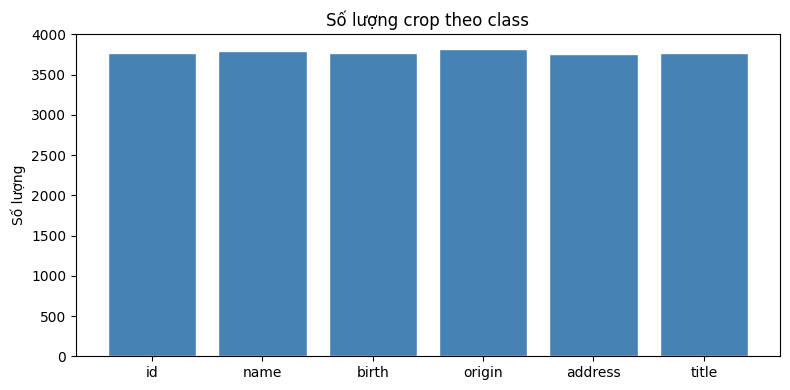

In [6]:
from collections import Counter

count_by_class = Counter(r["class"] for r in all_records)
count_by_split = Counter(r["split"] for r in all_records)
print("Số lượng crop theo class:")
for cls in FIELD_CLASSES:
    print(f"  {cls:10s}: {count_by_class.get(cls, 0):5d}")
print("Số lượng crop theo split:")
for split, cnt in count_by_split.items():
    print(f"  {split:6s}: {cnt}")

# Biểu đồ
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(FIELD_CLASSES, [count_by_class.get(c, 0) for c in FIELD_CLASSES], color="steelblue", edgecolor="white")
ax.set_title("Số lượng crop theo class")
ax.set_ylabel("Số lượng")
plt.tight_layout()
plt.show()

## 5. Xem thử một số crop mẫu

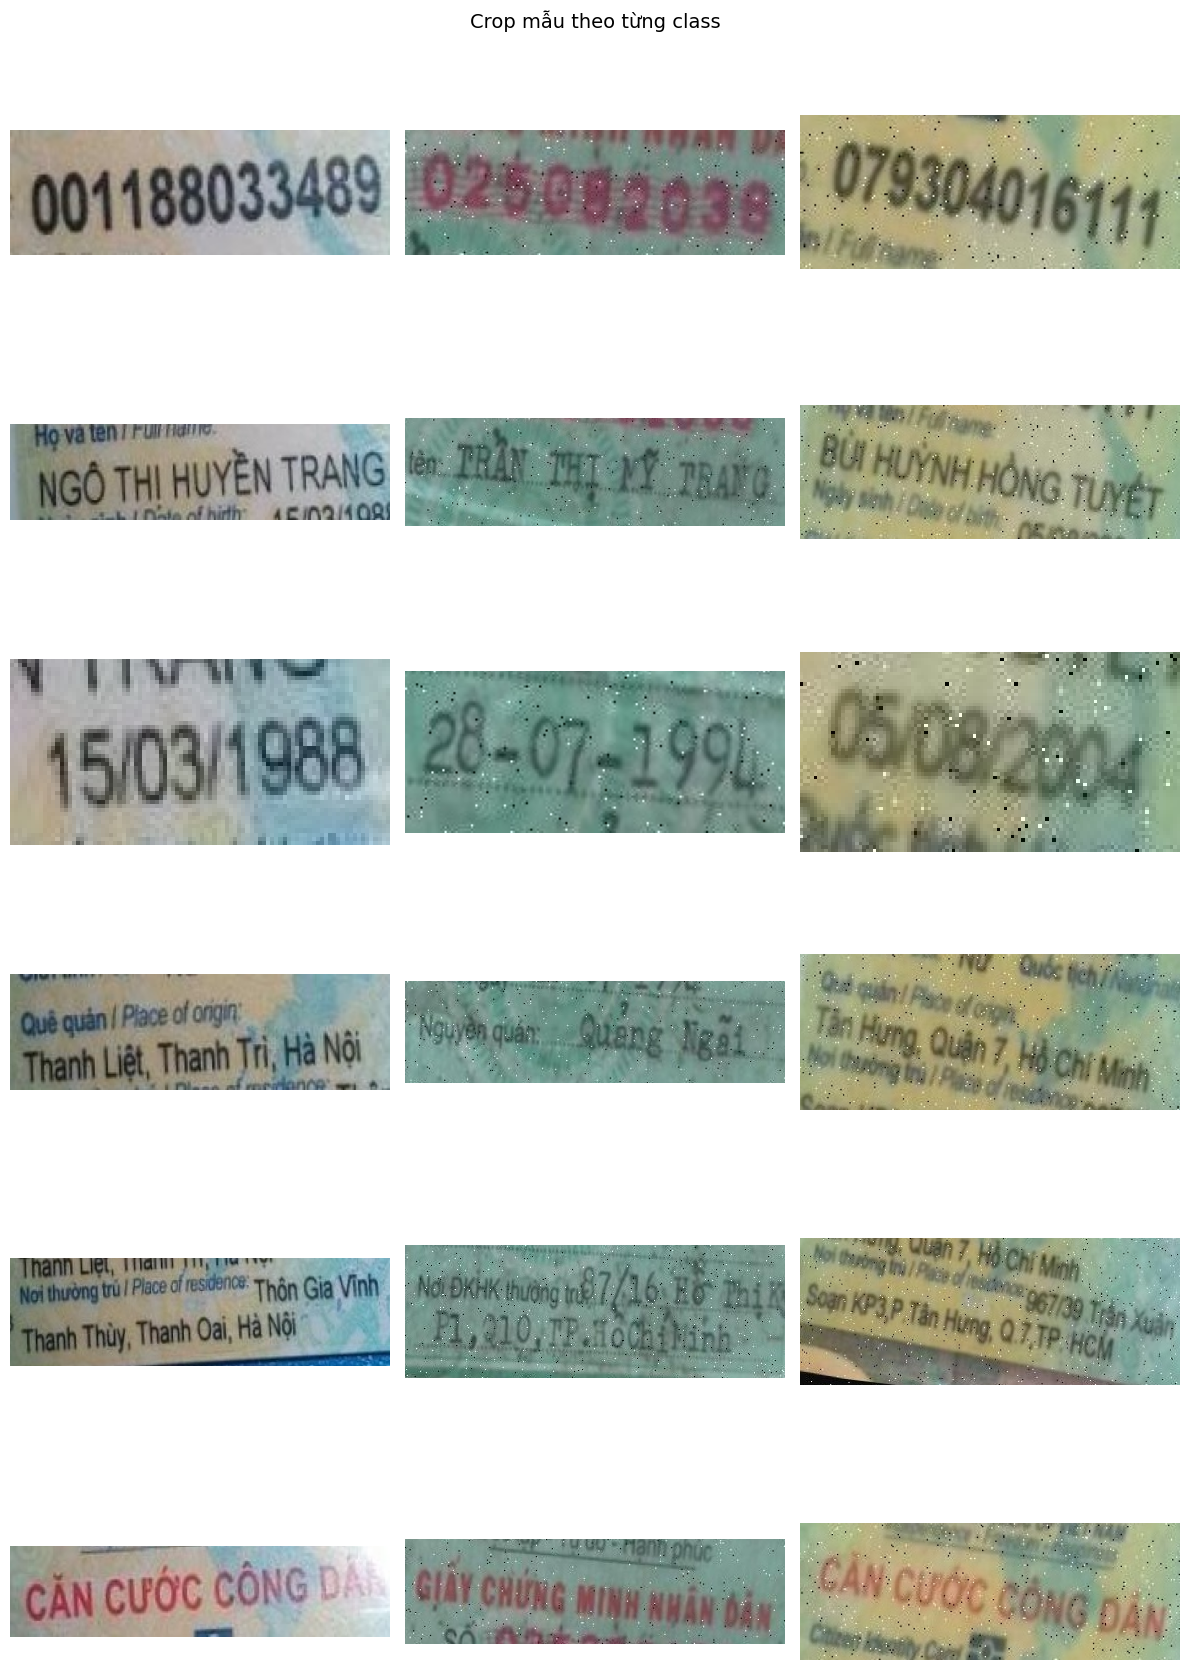

In [7]:
fig, axes = plt.subplots(len(FIELD_CLASSES), 3, figsize=(12, 3 * len(FIELD_CLASSES)))

for row, cls in enumerate(FIELD_CLASSES):
    samples = [r for r in all_records if r["class"] == cls][:3]
    for col, rec in enumerate(samples):
        img = cv2.imread(str(PROJECT_DIR / rec["path"]))
        if img is not None:
            axes[row][col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12)

plt.suptitle("Crop mẫu theo từng class", fontsize=14)
plt.tight_layout()
plt.show()